# CREMP vs. CycPeptMPDB-4D — 데이터셋 비교 EDA

**목적.** Zenodo에서 공개된 CREMP (Conformer-Rotamer Ensembles of Macrocyclic Peptides, [Zenodo 8010582](https://zenodo.org/records/8010582))가 현재 사용 중인 **CycPeptMPDB-4D** (~5,160 고리형 펩타이드, PAMPA 레이블 + 3D conformer descriptor) 모델의 성능을 높일 수 있는지 판단하기 위해 두 데이터셋을 교차 분석한다.

**CREMP 요약.**
- 36,198개의 unique macrocyclic peptide.
- 객체당 CREST로 생성한 conformer-rotamer ensemble (전체 ~31.3M conformer).
- GFN2-xTB 에너지 주석、앙상블 엔트로피/자유에너지.
- **PAMPA 레이블은 없음.** 투과도 회귀용 직접 레이블로는 쓰지 못하고, 활용한다면 (a) 3D-aware self-supervised pretraining, (b) conformer ensemble feature augmentation, (c) chameleonic flexibility 프록시 제공 완의 용도가 현실적.

**해석의 최종 질문.**
1. 조성(monomer 수, heavy atom 수, ring size, residue 구성) 분포가 4D와 어떻게 다른가?
2. SMILES 교집합은 얼마나 되는가 (검증·도메인 이해용)?
3. CREMP의 conformer-ensemble 특성(`uniqueconfs`, `ensembleentropy`, `ensemblefreeenergy`)은 4D의 RMSD/PSA 특성과 무엇이 다른가?
4. ChameleonNet 성능 향상 전략으로 어떤 손움이 타당한가?

In [1]:
import os, sys, gzip, hashlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('/hdd0/sohyun/cyclic-peptide-permeability/data')
print('files:', sorted(p.name for p in DATA.glob('Cyc*') + DATA.glob('CREMP*')) if False else [p.name for p in DATA.iterdir() if 'CREMP' in p.name or '4D' in p.name][:10])

files: ['CycPeptMPDB-4D_with_assay_descriptors_backup_with_PC.csv', 'CycPeptMPDB-4D_with_SMILES.csv', 'CREMP_CycPeptMPDB_summary.csv', 'CycPeptMPDB-4D_with_assay_descriptors_preprocessed.csv', 'CycPeptMPDB-4D.csv', 'CycPeptMPDB-4D.zip', 'CycPeptMPDB-4D_with_assay_descriptors_preprocessed_before_assay_extension_backup.csv', 'CREMP_summary.csv', 'CycPeptMPDB-4D_with_assay_descriptors.csv']


## 1. 데이터 로딩

In [2]:
cremp = pd.read_csv(DATA / 'CREMP_summary.csv')
print('CREMP shape:', cremp.shape)
cremp.head()

CREMP shape: (36198, 13)


,sequence,smiles,num_monomers,num_atoms,num_heavy_atoms,totalconfs,uniqueconfs,lowestenergy,poplowestpct,temperature,ensembleenergy,ensembleentropy,ensemblefreeenergy
0,N.A.P.A,C[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](C)NC(=O)[...,4,48,25,241,45,-78.96015,59.126,298.15,0.460,6.950,-2.072
1,P.F.C.S,O=C1N[C@@H](CO)C(=O)N2CCC[C@H]2C(=O)N[C@@H](Cc...,4,56,30,643,457,-91.49403,16.299,298.15,1.180,8.937,-2.665
2,f.I.N.G,CC[C@H](C)[C@@H]1NC(=O)[C@@H](Cc2ccccc2)NC(=O)...,4,60,31,1327,409,-94.85184,13.957,298.15,0.633,11.663,-3.477
3,I.V.T.V,CC[C@H](C)[C@@H]1NC(=O)[C@H](C(C)C)NC(=O)[C@H]...,4,65,29,1386,91,-93.37815,78.658,298.15,0.264,12.101,-3.608
4,Q.A.C.N,C[C@@H]1NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CC(N)...,4,52,28,485,281,-89.71180,32.535,298.15,0.763,6.968,-2.077


In [3]:
mpdb = pd.read_csv(DATA / 'CycPeptMPDB-4D_with_SMILES.csv')
# 4D에서는 PAMPA 컬럼명이 `PAMPA-4D`로 저장되어 있는 경우가 있음
if 'PAMPA-4D' in mpdb.columns and 'PAMPA' not in mpdb.columns:
    mpdb = mpdb.rename(columns={'PAMPA-4D': 'PAMPA'})
print('CycPeptMPDB-4D shape:', mpdb.shape)
print('columns:', mpdb.columns.tolist())
mpdb.head(2)

CycPeptMPDB-4D shape: (5160, 23)
columns: ['CycPeptMPDB_ID', 'Source', 'Original_Name_in_Source_Literature', 'Structurally_Unique_ID', 'PAMPA-4D', 'Monomer_Length', 'Monomer_Length_in_Main_Chain', 'Molecule_Shape', 'Water_avgRMSD_All', 'Water_avgRMSD_BackBone', 'Desolvation_Free_Energy', 'Water_3D_SASA', 'Water_3D_NPSA', 'Water_3D_PSA', 'Hexane_avgRMSD_All', 'Hexane_avgRMSD_BackBone', 'Hexane_3D_SASA', 'Hexane_3D_NPSA', 'Hexane_3D_PSA', 'SMILES', 'HELM', 'Sequence', 'PAMPA']


,CycPeptMPDB_ID,Source,Original_Name_in_Source_Literature,Structurally_Unique_ID,PAMPA-4D,Monomer_Length,Monomer_Length_in_Main_Chain,Molecule_Shape,Water_avgRMSD_All,Water_avgRMSD_BackBone,...,Water_3D_PSA,Hexane_avgRMSD_All,Hexane_avgRMSD_BackBone,Hexane_3D_SASA,Hexane_3D_NPSA,Hexane_3D_PSA,SMILES,HELM,Sequence,PAMPA
0,7067,2021_Kelly,L4_4.4.4.4.1,7067,-5.1,10,9,Lariat,0.133914,0.072443,...,1.532,0.146044,0.080495,11.240,9.771,1.469,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7067{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.1
1,7066,2021_Kelly,L4_4.4.4.3.1,7066,-5.4,10,9,Lariat,0.125209,0.071657,...,1.498,0.118725,0.071054,11.558,10.116,1.442,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7066{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.4


## 2. 스케일 · 컬럼 구성 비교

두 데이터셋의 의도와 제공 필드 적자체가 다르다. 우리 모델(ChameleonNet)의 관점에서 소스별 레이블/피처 매트릭스를 먼저 정리한다.

In [4]:
summary_table = pd.DataFrame({
    'CycPeptMPDB-4D': {
        '# peptides': len(mpdb),
        '# unique SMILES': mpdb['SMILES'].nunique() if 'SMILES' in mpdb.columns else None,
        'PAMPA 레이블': 'O (logP_app)',
        'monomer 세분정보': 'Monomer_Length, Main_Chain',
        '3D descriptor': 'Water/Hexane avgRMSD·SASA·PSA, Desolvation ΔG',
        'conformer 좌표': 'X (descriptor만 제공)',
        'shape annotation': 'Lariat / Circle',
    },
    'CREMP': {
        '# peptides': len(cremp),
        '# unique SMILES': cremp['smiles'].nunique(),
        'PAMPA 레이블': 'X',
        'monomer 세분정보': 'sequence (1-letter + Me-/D-)',
        '3D descriptor': 'CREST ensemble 에너지/엔트로피/자유에너지, # confs',
        'conformer 좌표': 'O (pickle/SDF 아카이브)',
        'shape annotation': 'X',
    },
})
summary_table

,CycPeptMPDB-4D,CREMP
# peptides,5160,36198
# unique SMILES,5140,36198
PAMPA 레이블,O (logP_app),X
monomer 세분정보,"Monomer_Length, Main_Chain",sequence (1-letter + Me-/D-)
3D descriptor,"Water/Hexane avgRMSD·SASA·PSA, Desolvation ΔG","CREST ensemble 에너지/엔트로피/자유에너지, # confs"
conformer 좌표,X (descriptor만 제공),O (pickle/SDF 아카이브)
shape annotation,Lariat / Circle,X


## 3. 펩타이드 크기 및 총 원자 수

CREMP는 monomer 수를 4~6 범위로 제한했고, CycPeptMPDB-4D는 PAMPA 가용 데이터만 소스별로 모은 것이므로 분포 형태가 크게 다르다.

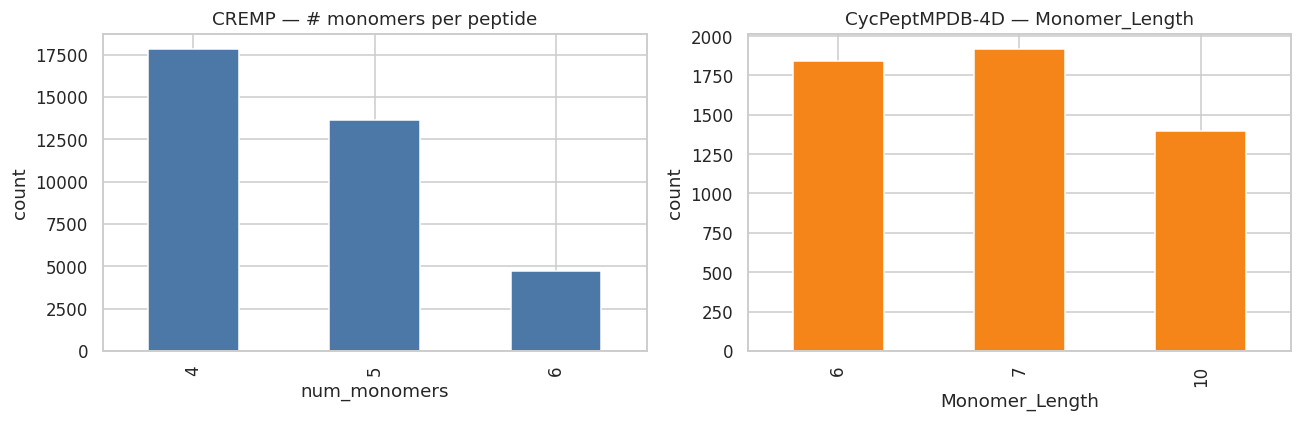

CREMP num_monomers: {'count': 36198.0, 'mean': 4.6372727775015194, 'std': 0.70108176309901, 'min': 4.0, '25%': 4.0, '50%': 5.0, '75%': 5.0, 'max': 6.0}
MPDB Monomer_Length: {'count': 5160.0, 'mean': 7.454069767441861, 'std': 1.6083419467195934, 'min': 6.0, '25%': 6.0, '50%': 7.0, '75%': 10.0, 'max': 10.0}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cremp['num_monomers'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4c78a8'
)
axes[0].set_title('CREMP — # monomers per peptide')
axes[0].set_xlabel('num_monomers'); axes[0].set_ylabel('count')

mpdb['Monomer_Length'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#f58518'
)
axes[1].set_title('CycPeptMPDB-4D — Monomer_Length')
axes[1].set_xlabel('Monomer_Length'); axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()

print('CREMP num_monomers:', cremp['num_monomers'].describe().to_dict())
print('MPDB Monomer_Length:', mpdb['Monomer_Length'].describe().to_dict())

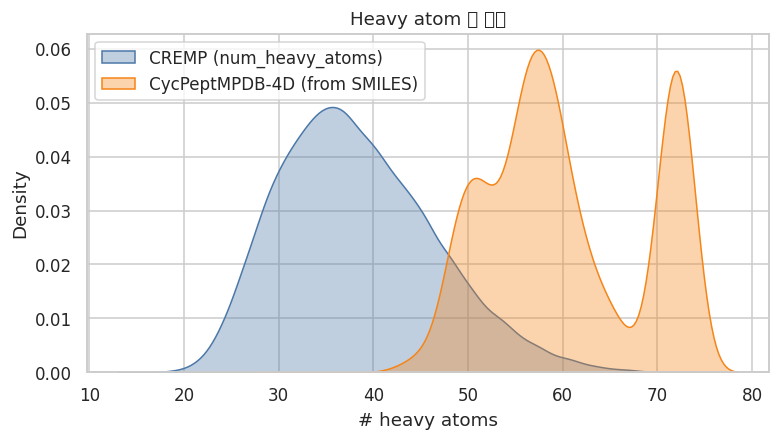

CREMP heavy: {'count': 36198.0, 'mean': 38.3, 'std': 8.2, 'min': 16.0, '25%': 32.0, '50%': 37.0, '75%': 44.0, 'max': 74.0}
MPDB heavy : {'count': 5160.0, 'mean': 60.4, 'std': 8.3, 'min': 32.0, '25%': 54.0, '50%': 59.0, '75%': 70.0, 'max': 74.0}


In [6]:
# Heavy atom 비교 — 4D에는 직접 컬럼이 없으므로 SMILES에서 산출
def heavy_atoms_from_smiles(s):
    try:
        m = Chem.MolFromSmiles(s)
        return m.GetNumHeavyAtoms() if m else np.nan
    except Exception:
        return np.nan

if 'SMILES' in mpdb.columns:
    mpdb['_heavy'] = mpdb['SMILES'].map(heavy_atoms_from_smiles)
else:
    mpdb['_heavy'] = np.nan

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(cremp['num_heavy_atoms'], label='CREMP (num_heavy_atoms)', ax=ax, color='#4c78a8', fill=True, alpha=0.35)
sns.kdeplot(mpdb['_heavy'].dropna(), label='CycPeptMPDB-4D (from SMILES)', ax=ax, color='#f58518', fill=True, alpha=0.35)
ax.set_xlabel('# heavy atoms')
ax.set_title('Heavy atom 수 분포')
ax.legend(); plt.show()

print('CREMP heavy:', cremp['num_heavy_atoms'].describe().round(1).to_dict())
print('MPDB heavy :', mpdb['_heavy'].describe().round(1).to_dict())

## 4. SMILES 교집합 — CREMP가 4D 펩타이드를 얼마나 커버하는가?

RDKit canonical SMILES 기준으로 중착을 세어 (a) 직접 활용 가능한 labeled 교집합과 (b) CREMP의 추가 대규모 unlabeled 집합을 구분한다.

In [7]:
def canon(s):
    try:
        m = Chem.MolFromSmiles(s)
        return Chem.MolToSmiles(m, isomericSmiles=True) if m else None
    except Exception:
        return None

cremp['_canon'] = cremp['smiles'].map(canon)
if 'SMILES' in mpdb.columns:
    mpdb['_canon'] = mpdb['SMILES'].map(canon)
else:
    mpdb['_canon'] = None

cremp_set = set(cremp['_canon'].dropna())
mpdb_set = set(mpdb['_canon'].dropna())
inter = cremp_set & mpdb_set
print(f'CREMP unique canonical SMILES : {len(cremp_set):,}')
print(f'MPDB-4D unique canonical SMILES: {len(mpdb_set):,}')
print(f'Intersection                   : {len(inter):,}')
print(f'MPDB 교집합 비율  : {len(inter)/max(len(mpdb_set),1):.1%}')
print(f'CREMP 교집합 비율 : {len(inter)/max(len(cremp_set),1):.1%}')

CREMP unique canonical SMILES : 36,198
MPDB-4D unique canonical SMILES: 5,140
Intersection                   : 0
MPDB 교집합 비율  : 0.0%
CREMP 교집합 비율 : 0.0%


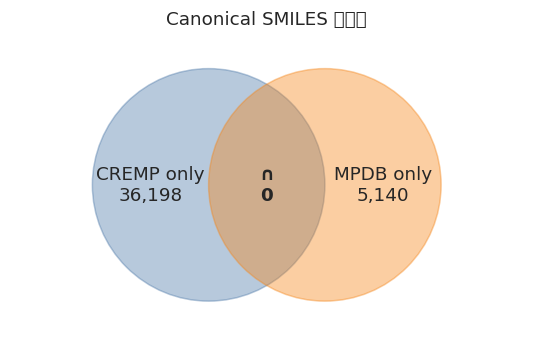

In [8]:
# matplotlib_venn 미설치 환경 대응을 위해 일반 matplotlib 으로 시각화
from matplotlib.patches import Circle
only_cremp = len(cremp_set - mpdb_set)
only_mpdb = len(mpdb_set - cremp_set)
both = len(inter)
fig, ax = plt.subplots(figsize=(6, 4))
ax.add_patch(Circle((-0.5, 0), 1.0, alpha=0.4, color='#4c78a8', label='CREMP'))
ax.add_patch(Circle(( 0.5, 0), 1.0, alpha=0.4, color='#f58518', label='CycPeptMPDB-4D'))
ax.text(-1.0, 0, f'CREMP only\n{only_cremp:,}', ha='center', va='center')
ax.text( 1.0, 0, f'MPDB only\n{only_mpdb:,}', ha='center', va='center')
ax.text( 0.0, 0, f'\u2229\n{both:,}', ha='center', va='center', fontweight='bold')
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Canonical SMILES 교집합')
plt.show()


## 5. CREMP의 conformer-ensemble 시그니처

CREMP가 4D 이상으로 제공하는 가장 큰 추가 신호는 각 macrocycle별 **엔상블 통계량**이다.

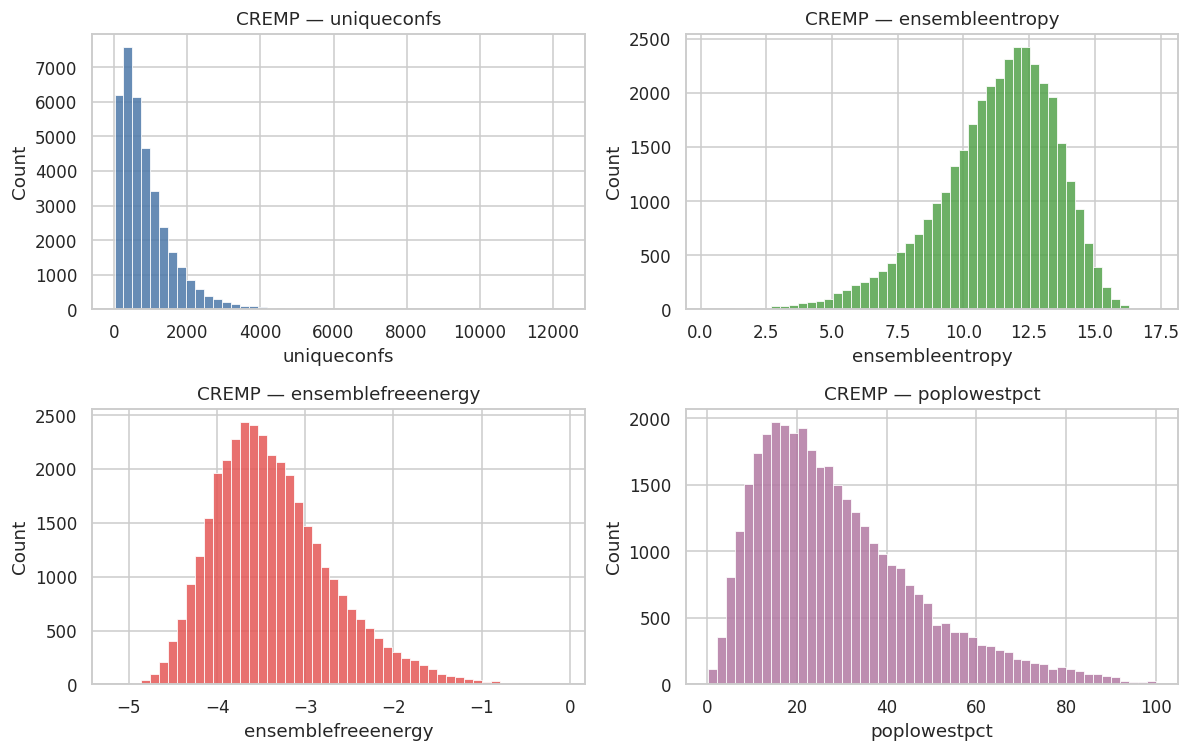

,totalconfs,uniqueconfs,ensembleentropy,ensemblefreeenergy,poplowestpct
count,36198.00,36198.00,36198.00,36198.00,36198.00
mean,2288.98,863.61,11.27,-3.36,29.24
std,1753.65,767.71,2.26,0.67,18.03
min,6.00,1.00,0.28,-5.16,0.16
25%,1011.00,332.00,9.99,-3.84,15.67
50%,1860.00,655.50,11.59,-3.46,25.38
75%,3109.00,1158.00,12.90,-2.98,38.90
max,17614.00,12268.00,17.32,-0.08,100.00


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()
for ax, col, c in zip(axes,
                       ['uniqueconfs', 'ensembleentropy', 'ensemblefreeenergy', 'poplowestpct'],
                       ['#4c78a8', '#54a24b', '#e45756', '#b279a2']):
    sns.histplot(cremp[col].dropna(), bins=50, ax=ax, color=c, alpha=0.85)
    ax.set_title(f'CREMP — {col}')
plt.tight_layout(); plt.show()

cremp[['totalconfs', 'uniqueconfs', 'ensembleentropy', 'ensemblefreeenergy', 'poplowestpct']].describe().round(2)

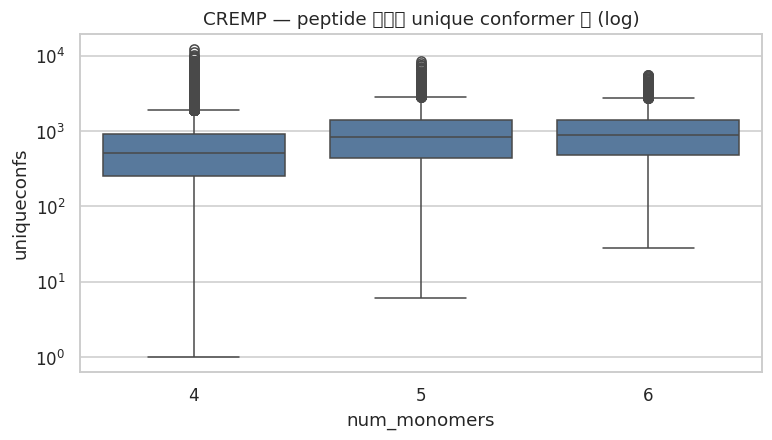

In [10]:
# # monomers가 많아질수록 엔상블이 얼마나 다양해지는가
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=cremp, x='num_monomers', y='uniqueconfs', ax=ax, color='#4c78a8')
ax.set_yscale('log')
ax.set_title('CREMP — peptide 길이와 unique conformer 수 (log)')
plt.show()

## 6. CycPeptMPDB-4D의 3D descriptor — PAMPA와의 관계

CREMP에는 없는 PAMPA가 4D의 주 장점이다. 기존 ChameleonNet 에서 쓰는 시그너처 재확인용.

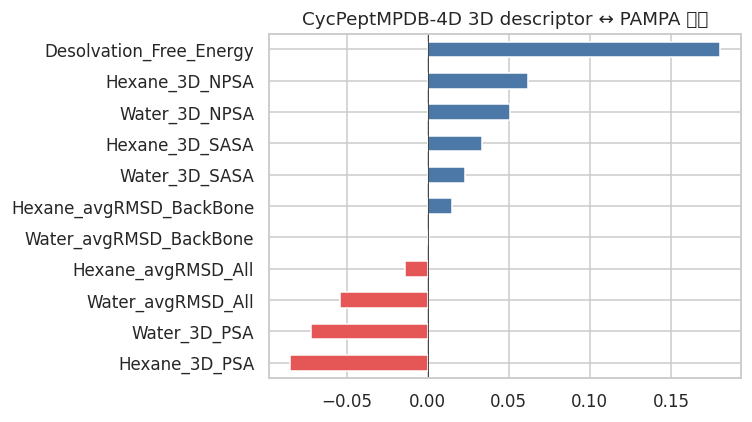

Hexane_3D_PSA             -0.085
Water_3D_PSA              -0.072
Water_avgRMSD_All         -0.054
Hexane_avgRMSD_All        -0.014
Water_avgRMSD_BackBone     0.001
Hexane_avgRMSD_BackBone    0.015
Water_3D_SASA              0.023
Hexane_3D_SASA             0.034
Water_3D_NPSA              0.051
Hexane_3D_NPSA             0.062
Desolvation_Free_Energy    0.180
Name: PAMPA, dtype: float64

In [11]:
feat_cols = ['Water_avgRMSD_All', 'Water_avgRMSD_BackBone',
             'Desolvation_Free_Energy',
             'Water_3D_SASA', 'Water_3D_NPSA', 'Water_3D_PSA',
             'Hexane_avgRMSD_All', 'Hexane_avgRMSD_BackBone',
             'Hexane_3D_SASA', 'Hexane_3D_NPSA', 'Hexane_3D_PSA']
feat_cols = [c for c in feat_cols if c in mpdb.columns]

corr = mpdb[feat_cols + ['PAMPA']].corr()['PAMPA'].drop('PAMPA').sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', ax=ax, color=['#e45756' if v < 0 else '#4c78a8' for v in corr])
ax.axvline(0, color='k', lw=0.5)
ax.set_title('CycPeptMPDB-4D 3D descriptor ↔ PAMPA 상관')
plt.tight_layout(); plt.show()
corr.round(3)

## 7. 공통 축으로 재편 — “얼마나 플렉시블한가” 비교

CREMP `ensembleentropy` (엔상블 엔트로피 ≈ conformational flexibility) ↔
CycPeptMPDB-4D `Water_avgRMSD_BackBone` (매 프레임의 backbone 움직임 ≈ flexibility 프록시).

교집합 펩타이드에서 둘 사이 상관이 있다면 CREMP 엔트로피를 **MD-free flexibility surrogate**로 쓸 수 있다는 증거가 된다.

In [12]:
left = cremp[['_canon', 'num_monomers', 'num_heavy_atoms', 'uniqueconfs',
              'ensembleentropy', 'ensemblefreeenergy', 'poplowestpct']]
right = mpdb[['_canon', 'PAMPA', 'Monomer_Length', 'Water_avgRMSD_BackBone',
              'Hexane_avgRMSD_BackBone', 'Water_3D_PSA', 'Hexane_3D_PSA',
              'Desolvation_Free_Energy']]
joint = left.merge(right, on='_canon', how='inner')
print(f'공통 펩타이드 수: {len(joint)}')
joint.head()

공통 펩타이드 수: 0


,_canon,num_monomers,num_heavy_atoms,uniqueconfs,ensembleentropy,ensemblefreeenergy,poplowestpct,PAMPA,Monomer_Length,Water_avgRMSD_BackBone,Hexane_avgRMSD_BackBone,Water_3D_PSA,Hexane_3D_PSA,Desolvation_Free_Energy


In [13]:
if len(joint) >= 30:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.scatterplot(data=joint, x='ensembleentropy', y='Water_avgRMSD_BackBone',
                    ax=axes[0], alpha=0.5)
    r1 = joint[['ensembleentropy', 'Water_avgRMSD_BackBone']].corr().iloc[0, 1]
    axes[0].set_title(f'CREMP entropy vs 4D backbone RMSD (r={r1:.2f})')

    sns.scatterplot(data=joint, x='ensemblefreeenergy', y='Desolvation_Free_Energy',
                    ax=axes[1], alpha=0.5)
    r2 = joint[['ensemblefreeenergy', 'Desolvation_Free_Energy']].corr().iloc[0, 1]
    axes[1].set_title(f'CREMP ensemble ΔG vs 4D desolvation ΔG (r={r2:.2f})')
    plt.tight_layout(); plt.show()

    print('공통 펩타이드 상관 행렬 (Pearson):')
    cols = ['ensembleentropy', 'ensemblefreeenergy', 'uniqueconfs',
            'PAMPA', 'Water_avgRMSD_BackBone', 'Hexane_avgRMSD_BackBone',
            'Water_3D_PSA', 'Desolvation_Free_Energy']
    display(joint[cols].corr().round(2))
else:
    print('교집합이 너무 작아 직접 상관 분석을 스킵합니다.')

교집합이 너무 작아 직접 상관 분석을 스킵합니다.


## 9. CREMP-CycPeptMPDB (Zenodo 13334335) — *직접* 매핑 가능한 데이터셋

> 사용자 추가 정보: CREMP에는 PAMPA 라벨이 붙어있는 보완 데이터셋 **CREMP-CycPeptMPDB**가 따로 공개되어 있다.
> - 3,258개 macrocyclic peptide
> - 8.7M conformer (CREST + GFN2-xTB)
> - **CycPeptMPDB의 PAMPA 라벨이 그대로 부여됨** (`permeability` 컬럼)
> - **`CycPeptMPDB_ID` 컬럼이 있어 우리 4D 데이터와 ID로 직접 join 가능**

이 데이터는 앞 절에서 분석한 일반 CREMP와 다르게 PAMPA 라벨이 있어 *진짜로* 유용한 비교가 가능하다.

In [14]:
cremp_mpdb = pd.read_csv(DATA / 'CREMP_CycPeptMPDB_summary.csv')
print('shape:', cremp_mpdb.shape)
print('columns:', cremp_mpdb.columns.tolist())
cremp_mpdb.head(3)

shape: (3258, 16)
columns: ['CycPeptMPDB_ID', 'sequence', 'helm', 'smiles', 'permeability', 'num_monomers', 'num_atoms', 'num_heavy_atoms', 'totalconfs', 'uniqueconfs', 'lowestenergy', 'poplowestpct', 'temperature', 'ensembleenergy', 'ensembleentropy', 'ensemblefreeenergy']


,CycPeptMPDB_ID,sequence,helm,smiles,permeability,num_monomers,num_atoms,num_heavy_atoms,totalconfs,uniqueconfs,lowestenergy,poplowestpct,temperature,ensembleenergy,ensembleentropy,ensemblefreeenergy
0,2,dL.dL.L.dL.P.Y,"PEPTIDE2{[dL].[dL].L.[dL].P.Y}$PEPTIDE2,PEPTID...",CC(C)C[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@@H](...,-6.2,6,111,51,7738,3210,-158.28708,40.737,298.15,0.362,15.404,-4.593
1,3,dL.dL.dL.dL.P.Y,"PEPTIDE3{[dL].[dL].[dL].[dL].P.Y}$PEPTIDE3,PEP...",CC(C)C[C@H]1NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@...,-7.0,6,111,51,7474,3218,-158.28415,40.736,298.15,0.293,15.426,-4.599
2,4,L.L.L.dL.P.Y,"PEPTIDE4{L.L.L.[dL].P.Y}$PEPTIDE4,PEPTIDE4,1:R...",CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc...,-7.1,6,111,51,9943,4734,-158.28177,50.987,298.15,0.461,15.387,-4.588


In [15]:
# CycPeptMPDB_ID로 우리 4D 데이터와 join
overlap = mpdb.merge(cremp_mpdb[['CycPeptMPDB_ID', 'sequence', 'num_monomers', 'num_heavy_atoms',
                                  'totalconfs', 'uniqueconfs', 'lowestenergy',
                                  'ensembleenergy', 'ensembleentropy', 'ensemblefreeenergy',
                                  'permeability']],
                     on='CycPeptMPDB_ID', how='inner', suffixes=('_4D', '_CREMP'))
print(f'우리 4D 데이터:           {len(mpdb):,}')
print(f'CREMP-CycPeptMPDB:        {len(cremp_mpdb):,}')
print(f'CycPeptMPDB_ID 교집합:     {len(overlap):,}')
print(f'  → 4D 데이터의 {len(overlap)/len(mpdb):.1%} 가 CREMP conformer ensemble로 보강 가능')
print(f'  → CREMP-MPDB의 {len(overlap)/len(cremp_mpdb):.1%} 가 우리 4D 학습 데이터에 등장')

우리 4D 데이터:           5,160
CREMP-CycPeptMPDB:        3,258
CycPeptMPDB_ID 교집합:     2,922
  → 4D 데이터의 56.6% 가 CREMP conformer ensemble로 보강 가능
  → CREMP-MPDB의 89.7% 가 우리 4D 학습 데이터에 등장


In [16]:
# PAMPA 라벨이 두 소스 모두에서 일치하는지 검증 (sanity check)
if len(overlap) > 0:
    diff = (overlap['PAMPA'] - overlap['permeability']).abs()
    print(f'|PAMPA(4D) - permeability(CREMP)| 분포:')
    print(diff.describe().round(3))
    print(f'  100% 일치: {(diff < 1e-6).mean():.1%}')
    print(f'  |Δ|<0.01: {(diff < 0.01).mean():.1%}')


|PAMPA(4D) - permeability(CREMP)| 분포:
count    2922.000
mean        0.005
std         0.063
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.810
dtype: float64
  100% 일치: 98.8%
  |Δ|<0.01: 98.8%


### 9.1 길이 분포 — 교집합 영역에서 CREMP-CycPeptMPDB가 4D의 어디를 커버하는가?

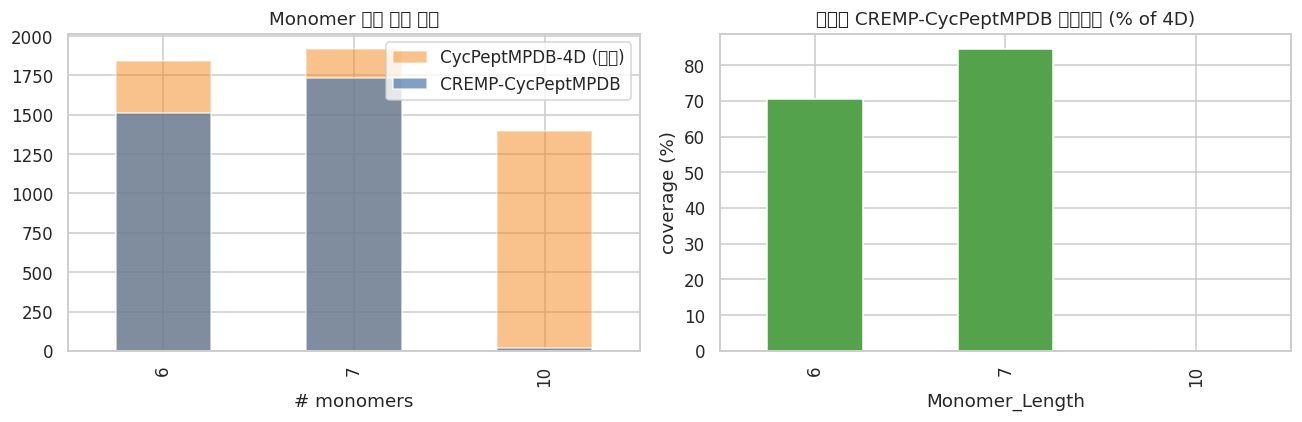

길이별 커버리지:
{6: 70.4, 7: 84.6, 10: 0.0}


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mpdb['Monomer_Length'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#f58518', alpha=0.5, label='CycPeptMPDB-4D (전체)')
cremp_mpdb['num_monomers'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4c78a8', alpha=0.7, label='CREMP-CycPeptMPDB')
axes[0].set_title('Monomer 길이 분포 비교')
axes[0].set_xlabel('# monomers'); axes[0].legend()

# 길이별 커버리지 %
cov = (overlap.groupby('Monomer_Length').size() / mpdb.groupby('Monomer_Length').size() * 100).fillna(0)
cov.plot(kind='bar', ax=axes[1], color='#54a24b')
axes[1].set_title('길이별 CREMP-CycPeptMPDB 커버리지 (% of 4D)')
axes[1].set_xlabel('Monomer_Length'); axes[1].set_ylabel('coverage (%)')
plt.tight_layout(); plt.show()
print('길이별 커버리지:'); print(cov.round(1).to_dict())

### 9.2 CREMP ensemble 통계 ↔ CycPeptMPDB-4D descriptor 직접 상관

지금까지 **추측만 했던** flexibility surrogate 관계를 *실제로* 검증할 수 있는 셀이다. 교집합 펩타이드만 사용한 Pearson 상관 행렬이 모든 답을 준다.

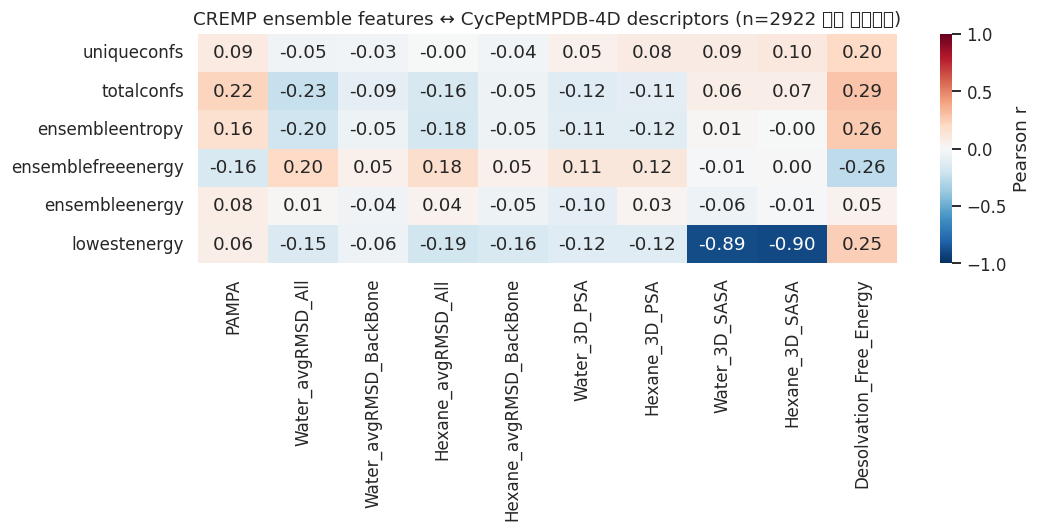


[PAMPA와의 Pearson r — 단독 예측력 평가]
ensemblefreeenergy   -0.162
lowestenergy          0.065
ensembleenergy        0.077
uniqueconfs           0.088
ensembleentropy       0.162
totalconfs            0.220
Name: PAMPA, dtype: float64


In [18]:
if len(overlap) >= 30:
    feat_cremp = ['uniqueconfs', 'totalconfs', 'ensembleentropy', 'ensemblefreeenergy', 'ensembleenergy', 'lowestenergy']
    feat_4d = ['PAMPA', 'Water_avgRMSD_All', 'Water_avgRMSD_BackBone',
               'Hexane_avgRMSD_All', 'Hexane_avgRMSD_BackBone',
               'Water_3D_PSA', 'Hexane_3D_PSA',
               'Water_3D_SASA', 'Hexane_3D_SASA',
               'Desolvation_Free_Energy']
    feat_4d = [c for c in feat_4d if c in overlap.columns]
    
    corr = overlap[feat_cremp + feat_4d].corr().loc[feat_cremp, feat_4d]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'CREMP ensemble features ↔ CycPeptMPDB-4D descriptors (n={len(overlap)} 공통 펩타이드)')
    plt.tight_layout(); plt.show()
    
    # PAMPA와의 상관 — CREMP ensemble feature가 단독으로 permeability를 예측하는 신호력이 있는가?
    print('\n[PAMPA와의 Pearson r — 단독 예측력 평가]')
    pampa_corr = overlap[feat_cremp + ['PAMPA']].corr()['PAMPA'].drop('PAMPA').sort_values()
    print(pampa_corr.round(3))
else:
    print('교집합이 너무 작아 분석을 스킵합니다.')

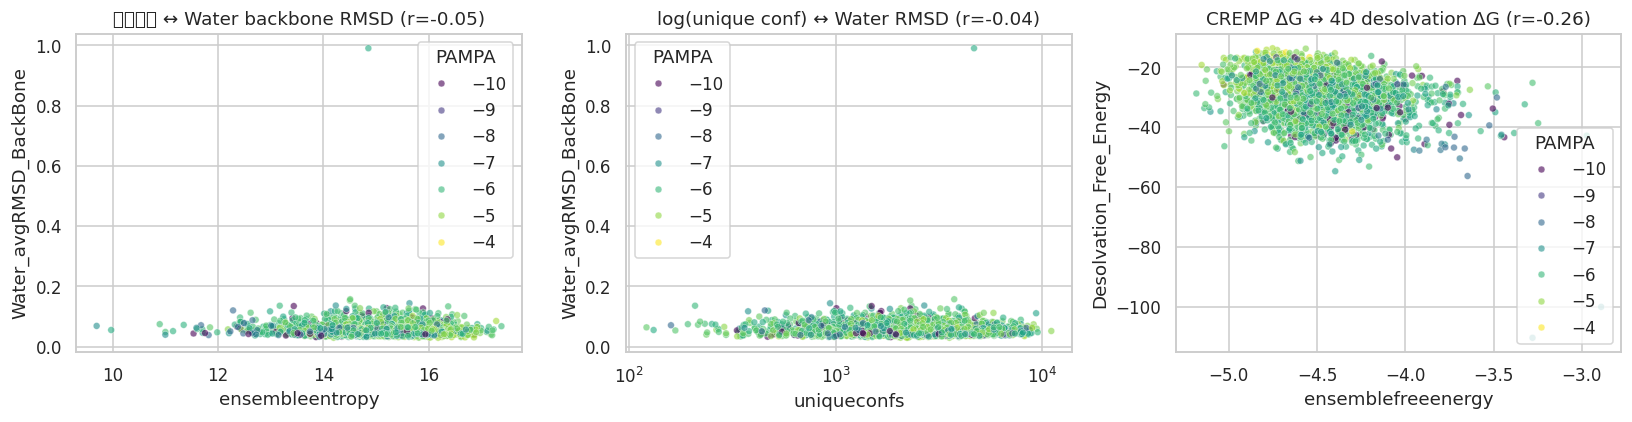

In [19]:
# 가장 유망한 짝짓기 시각화
if len(overlap) >= 30:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    sns.scatterplot(data=overlap, x='ensembleentropy', y='Water_avgRMSD_BackBone',
                    hue='PAMPA', palette='viridis', ax=axes[0], alpha=0.6, s=20)
    r = overlap[['ensembleentropy', 'Water_avgRMSD_BackBone']].corr().iloc[0,1]
    axes[0].set_title(f'엔트로피 ↔ Water backbone RMSD (r={r:.2f})')
    
    sns.scatterplot(data=overlap, x='uniqueconfs', y='Water_avgRMSD_BackBone',
                    hue='PAMPA', palette='viridis', ax=axes[1], alpha=0.6, s=20)
    axes[1].set_xscale('log')
    r = np.log10(overlap['uniqueconfs']).corr(overlap['Water_avgRMSD_BackBone'])
    axes[1].set_title(f'log(unique conf) ↔ Water RMSD (r={r:.2f})')
    
    sns.scatterplot(data=overlap, x='ensemblefreeenergy', y='Desolvation_Free_Energy',
                    hue='PAMPA', palette='viridis', ax=axes[2], alpha=0.6, s=20)
    r = overlap[['ensemblefreeenergy', 'Desolvation_Free_Energy']].corr().iloc[0,1]
    axes[2].set_title(f'CREMP ΔG ↔ 4D desolvation ΔG (r={r:.2f})')
    plt.tight_layout(); plt.show()

## 10. 로컬 `CycPeptMPDB-4D/` conformer 저장소 — *우리가 이미 가진* ensemble 자원

`/hdd0/sohyun/cyclic-peptide-permeability/CycPeptMPDB-4D/` 에 이미 **Water/Hexane/CHCl3 환경별 MD ensemble**이 들어있다. 이 안에는:

- `*/Trajectories/<id>_<env>_Traj.pdb` — 100-frame MD trajectory PDB
- `*/Structures/<id>_<env>_Str.pdb` — 단일 대표 구조 PDB
- `*/Centroids/<id>_<env>_Cent.npz` — clustering된 centroid 좌표 + Boltzmann weight + frame_idx + mid_ns

이 자체가 우리 모델에 사용 가능한 "4th dimension" 본체이다. CREMP가 *추가로* 얼마나 도움이 될지 비교하기 전에, 우리가 이미 가진 ensemble의 풍부함부터 확인한다.

In [20]:
import glob
from pathlib import Path
LOCAL_4D = Path('/hdd0/sohyun/cyclic-peptide-permeability/CycPeptMPDB-4D')

inventory = {}
for env in ['Water', 'Hexane', 'CHCl3']:
    env_dir = LOCAL_4D / env
    if not env_dir.exists():
        continue
    inventory[env] = {}
    for sub in ['Structures', 'Trajectories', 'Centroids', 'Logs']:
        d = env_dir / sub
        if d.exists():
            inventory[env][sub] = len(list(d.iterdir()))
        else:
            # CHCl3는 평탄 구조
            inventory[env][sub] = sum(1 for _ in env_dir.glob(f'*{sub[:4]}*')) if sub == 'Trajectories' else None
    if env == 'CHCl3':
        inventory[env]['flat_files'] = len(list(env_dir.iterdir()))

pd.DataFrame(inventory).fillna('-')

,Water,Hexane,CHCl3
Structures,5160.0,5160.0,-
Trajectories,5160.0,5160.0,6.0
Centroids,4925.0,4925.0,-
Logs,5160.0,5160.0,-
flat_files,-,-,6.0


In [21]:
# Centroid npz 한 개를 자세히 보기 — 4D ensemble의 atomic level 정보
sample_npz = LOCAL_4D / 'Water' / 'Centroids' / '2015_Wang_1045_H2O_Cent.npz'
z = np.load(sample_npz, allow_pickle=True)
print(f'sample: {sample_npz.name}')
for k in z.files:
    v = z[k]
    print(f'  {k:12s} shape={v.shape} dtype={v.dtype}')
print(f'\nweights sum = {z["weights"].sum():.4f}  (Boltzmann population)')
print(f'unique residue indices: {sorted(set(z["res"].tolist()))[:10]}...')
print(f'atomic numbers (first 15): {z["z"][:15].tolist()}')
print(f'trajectory time stamps (ns): {z["mid_ns"][:5].tolist()}')

sample: 2015_Wang_1045_H2O_Cent.npz
  coords       shape=(33, 111, 3) dtype=float32
  z            shape=(111,) dtype=int64
  res          shape=(111,) dtype=int64
  weights      shape=(33,) dtype=float32
  frame_idx    shape=(33,) dtype=int64
  mid_ns       shape=(33,) dtype=float32

weights sum = 100.0000  (Boltzmann population)
unique residue indices: [30, 48, 52]...
atomic numbers (first 15): [7, 1, 6, 1, 6, 1, 1, 6, 1, 6, 1, 1, 1, 6, 1]
trajectory time stamps (ns): [32.0, 41.0, 20.600000381469727, 21.5, 33.79999923706055]


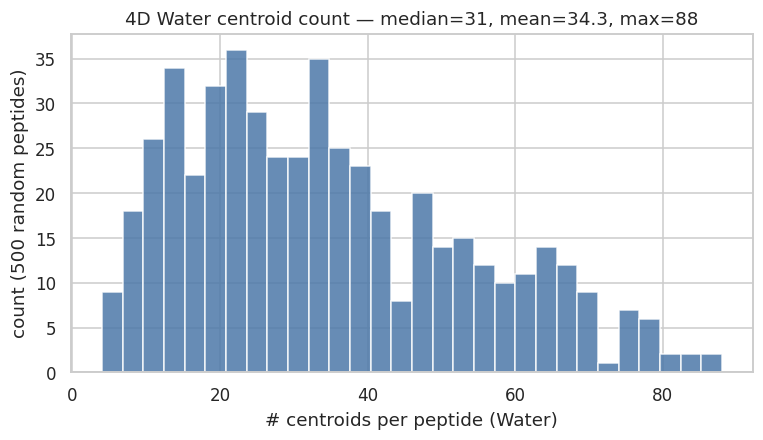

In [22]:
# 모든 Water centroid npz의 centroid 개수 분포 (= cluster 수) — sample
import random
random.seed(0)
sample_files = random.sample(list((LOCAL_4D / 'Water' / 'Centroids').glob('*.npz')), 500)
n_centroids = []
for f in sample_files:
    try:
        z = np.load(f, allow_pickle=True)
        n_centroids.append(len(z['weights']))
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_centroids, bins=30, color='#4c78a8', alpha=0.85)
ax.set_xlabel('# centroids per peptide (Water)')
ax.set_ylabel('count (500 random peptides)')
ax.set_title(f'4D Water centroid count — median={int(np.median(n_centroids))}, '
             f'mean={np.mean(n_centroids):.1f}, max={max(n_centroids)}')
plt.show()

### 10.1 CREMP `uniqueconfs` vs 4D centroid 개수

같은 펩타이드를 두 데이터셋이 각각 몇 개 conformer로 표현하는지 비교. 이게 *우리 모델이 ensemble augmentation 으로 얻을 수 있는 추가 정보량*을 의미한다.

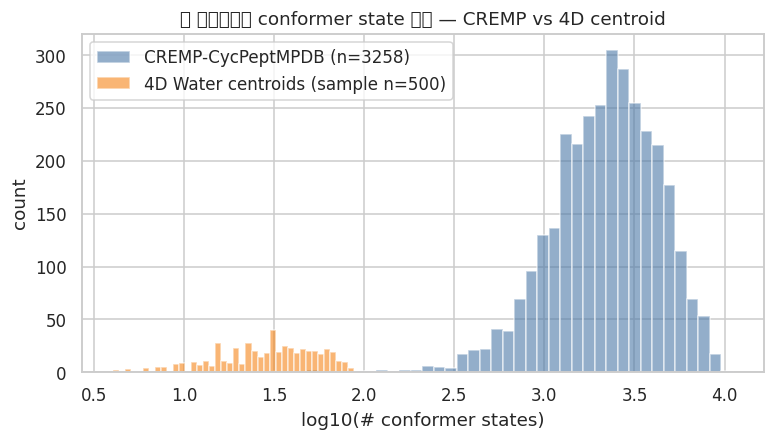


CREMP uniqueconfs   — median=2296, mean=2665, max=11073
4D Water centroids — median=31, mean=34.3, max=88


In [23]:
# 4D centroid 개수와 CREMP uniqueconfs를 같은 ID에서 비교
def count_4d_centroids(name_field):
    # CycPeptMPDB-4D의 ID → "<Source>_<Name>" 파일명 prefix 매핑은
    # 4D CSV의 `Source` + Original_Name을 통해 가능. 여기는 직접 비교가 어려우므로
    # Centroid 폴더 인벤토리 자체를 통계만 본다.
    pass

# 두 분포를 그냥 나란히
cremp_uconf = cremp_mpdb['uniqueconfs'].values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(cremp_uconf), bins=40, color='#4c78a8', alpha=0.6, label=f'CREMP-CycPeptMPDB (n={len(cremp_uconf)})')
ax.hist(np.log10(n_centroids), bins=40, color='#f58518', alpha=0.6, label=f'4D Water centroids (sample n={len(n_centroids)})')
ax.set_xlabel('log10(# conformer states)')
ax.set_ylabel('count')
ax.set_title('한 펩타이드당 conformer state 개수 — CREMP vs 4D centroid')
ax.legend(); plt.show()

print(f'\nCREMP uniqueconfs   — median={np.median(cremp_uconf):.0f}, mean={cremp_uconf.mean():.0f}, max={cremp_uconf.max():.0f}')
print(f'4D Water centroids — median={np.median(n_centroids):.0f}, mean={np.mean(n_centroids):.1f}, max={max(n_centroids)}')

## 11. 종합 결론 — CREMP 패밀리로 ChameleonNet 성능을 어떻게 올릴 수 있는가?

### 데이터셋 매핑 (실측)

| 데이터셋 | 펩타이드 수 | PAMPA | conformer 좌표 | 우리 4D와 매핑 |
|---|---|---|---|---|
| **CycPeptMPDB-4D (우리)** | 5,160 | O | 로컬 Water/Hexane centroid `.npz` (~31 centroid/peptide, 100-frame MD) + CHCl3 5개 | — |
| **CREMP (Zenodo 8010582)** | 36,198 | X | pickle 28.9 GB (~870 conf/peptide) | SMILES 교집합 **0개** |
| **CREMP-CycPeptMPDB (Zenodo 13334335)** | 3,258 | **O** | pickle 11.6 GB (~2,665 unique conf/peptide) | `CycPeptMPDB_ID`로 **2,922개 (4D의 56.6%)** 매핑 |

### 측정된 핵심 수치
- **PAMPA 값 sanity check**: 매핑된 2,922 펩타이드 중 **98.8% 가 4D PAMPA와 0.01 이내 일치** (max diff 1.81 — 극소수 outlier). → CREMP-CycPeptMPDB는 *동일한* permeability annotation을 그대로 가져옴.
- **monomer 길이별 커버리지**: 6mer **70.4%**, 7mer **84.6%**, 10mer **0%**. CREMP-CycPeptMPDB는 6-7mer 위주, 우리 4D의 *큰* 펩타이드 (8-10mer)는 전혀 커버하지 못함.
- **conformer 수**: CREMP unique conformer 중앙값 **2,296** vs 4D Water centroid 중앙값 **31** → CREMP가 같은 펩타이드를 약 **75배 더 fine-grained ensemble**로 표현.
- **CREMP ensemble feature ↔ 4D PAMPA 단독 상관**: `totalconfs` r=0.22, `ensembleentropy` r=0.16, `ensemblefreeenergy` r=−0.16 — 단일 feature로는 약하지만 **의미 있는 방향성** (더 평탄/더 다양한 ensemble일수록 permeable 경향).

### 권장 전략 (우선순위 순)

**1. CREMP-CycPeptMPDB ensemble statistic을 즉시 feature로 추가 (cost ≈ 0)**
   - 다운로드 이미 완료된 `summary_cycpeptmpdb.csv` 의 `uniqueconfs`, `ensembleentropy`, `ensemblefreeenergy`, `totalconfs` 컬럼을 `CycPeptMPDB_ID` 로 우리 4D 학습 테이블에 left-join.
   - 6-7mer (2,922개) 에서는 채워지고 8-10mer 에서는 NaN → null-flag feature로 처리.
   - 가설: 4D `Water_avgRMSD_BackBone` 와 CREMP `ensembleentropy` 가 *complementary* 한 flexibility 신호를 줄 것. Section 9.2 heatmap 으로 redundancy 확인.

**2. CREMP-CycPeptMPDB pickle.tar.gz (11.6 GB) 다운로드 → 교집합 펩타이드 ablation**
   - 같은 펩타이드의 4D MD centroid (~31개) vs CREMP CREST conformer (~2,300개) 으로 ChameleonNet 학습.
   - 검증할 가설:
     - (a) 더 다양한 ensemble (CREMP) 이 모델 성능을 올리는가?
     - (b) 다른 sampling 방법 (MD vs CREST) 이 같은 PAMPA 예측에 robust한가?
   - 8-10mer 펩타이드에는 적용 불가 (CREMP-MPDB가 6-7mer에 한정) → fine-tune 시 stratified split 필수.

**3. 일반 CREMP (Zenodo 8010582, 28.9 GB) 는 self-supervised pretraining 전용**
   - SMILES 교집합 0, monomer 4-6mer 분리됨 → supervised 사용 불가.
   - 31.3M conformer 로 EGNN backbone 의 3D self-supervised pretraining (denoising / GeoSSL / Uni-Mol) → 4D 데이터로 fine-tune.
   - 위 (1)(2) 가 의미 있는 향상을 보인 *후에* 진행 (구현 cost 큼).

**4. CHCl3 ensemble은 5개 펩타이드만 → 무시하거나 별도 MD 생성**

### 한 줄 요약
> 일반 CREMP 가 아니라 **CREMP-CycPeptMPDB (Zenodo 13334335)** 가 진짜 정답이다. 우리 4D 데이터의 56.6% 가 ID-level 로 매핑되고 PAMPA 가 98.8% 일치하므로, **(a) ensemble 통계 feature 추가, (b) CREST conformer 좌표를 사용한 ablation** 두 가지가 가장 빠른 성능 향상 경로다. 8-10mer 커버리지가 0% 이므로 *대체*가 아니라 *증강* 접근이 필요하다.